In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import datetime as dt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.decomposition import PCA 
from sklearn.cluster import KMeans, AgglomerativeClustering
from kneed import KneeLocator
from sklearn.metrics import silhouette_score


In [2]:

df = pd.read_csv("datasets/smartcart_customers.csv")

In [3]:
# df.head()
# df.shape
# df.describe()
# df.info()
# df.isna().sum()


### Handling Missing value

In [4]:
df["Income"] = df["Income"].fillna(df["Income"].median())

# Feature Engineering

In [5]:
df["Age"] = 2026 - df["Year_Birth"]

In [6]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date = df["Dt_Customer"].max()
df["Cutomer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [7]:
# df.head()
# df.columns


In [8]:
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"] 

In [9]:
# df.head()
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]   

In [10]:
# df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic" : "Undergraduate",
    "2n Cycle" : "Undergraduate",
    "Graduation" : "Graduate",
    "Master" : "Postgraduate",
    "PhD" : "Postgraduate"
})

df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [11]:

df["Living_With"] = df["Marital_Status"].replace({
    "Married" : "Partner",
    "Together" : "Partner",
    "Single" : "Alone",
    "Divorced" : "Alone", "Widow" : "Alone", "YOLO" : "Alone" , "Absurd" : "Alone"
})
df["Living_With"].value_counts()



Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

### Drop Columns

In [12]:
# df.columns


cols = ["ID","Year_Birth", "Marital_Status",
        "Kidhome","Teenhome","Dt_Customer"]

spending_col = ["MntWines","MntFruits","MntMeatProducts", "MntFishProducts",
               "MntSweetProducts","MntGoldProds"]
cols_to_drop = cols + spending_col

df_cleaned = df.drop(columns=cols_to_drop, axis=1)

In [13]:
# print(df_cleaned.shape)
# print(df.shape)

# df_cleaned.info()

## Removing Outliers

In [14]:
cols = ["Income", "Recency", "Age", "Total_Spending", "Total_Children"]
# sns.pairplot(df_cleaned[cols])

print("data size with outliers:",len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600000)]

print("data size without outliers:", len(df_cleaned))

data size with outliers: 2240
data size without outliers: 2236


## Heatmap 

<Axes: >

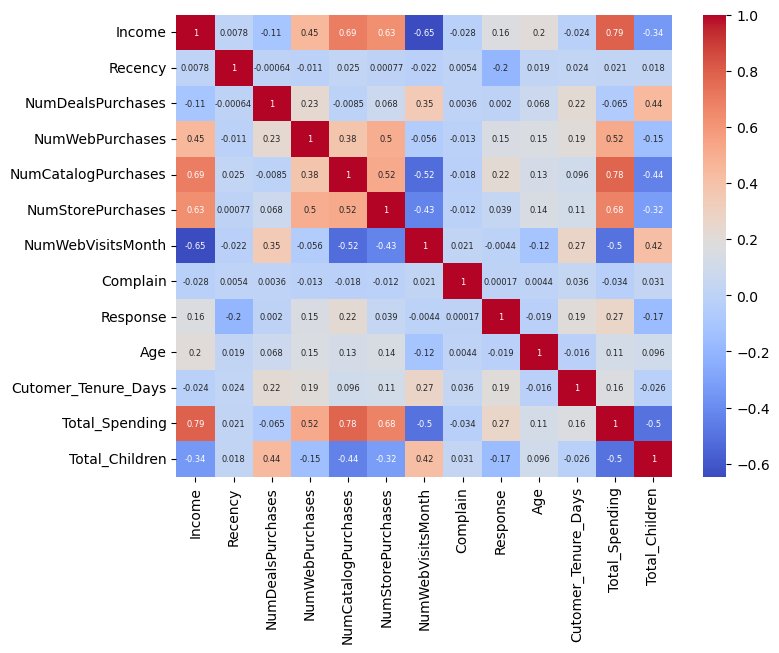

In [15]:
corr = df_cleaned.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot_kws= {"size":6},
    annot= True,
    cmap= "coolwarm"
    
)

In [16]:
df_cleaned.head()

ohe = OneHotEncoder()
cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [17]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)
enc_df.head(3)

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0


In [18]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)


In [19]:
df_encoded.head(3)
X = df_encoded

In [20]:
scalar = StandardScaler()
X_scaled = scalar.fit_transform(X)
X_scaled.shape

(2236, 18)

In [21]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3D Projection')

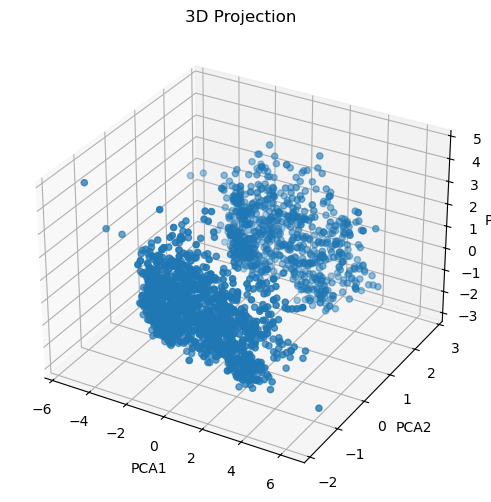

In [22]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Projection")



In [23]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

## Modelling

In [24]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [25]:
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow
print("best k =", optimal_k)

best k = 4


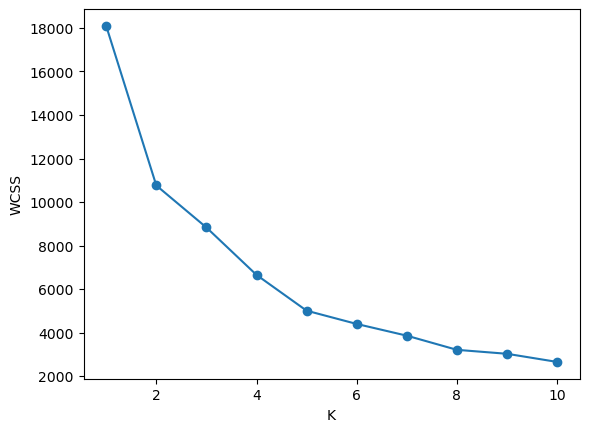

In [45]:
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("K");
plt.ylabel("WCSS");

Text(0, 0.5, 'Sihouette Score')

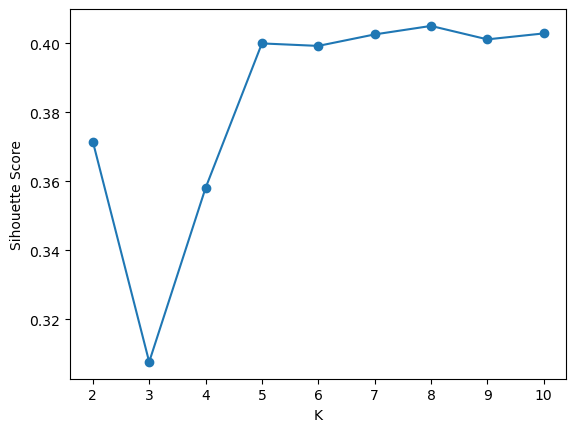

In [27]:
# Silhouette Score 

scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)

plt.plot(range(2,11),scores,marker='o')
plt.xlabel("K")
plt.ylabel("Sihouette Score")

Text(0, 0.5, 'Silhouette Score')

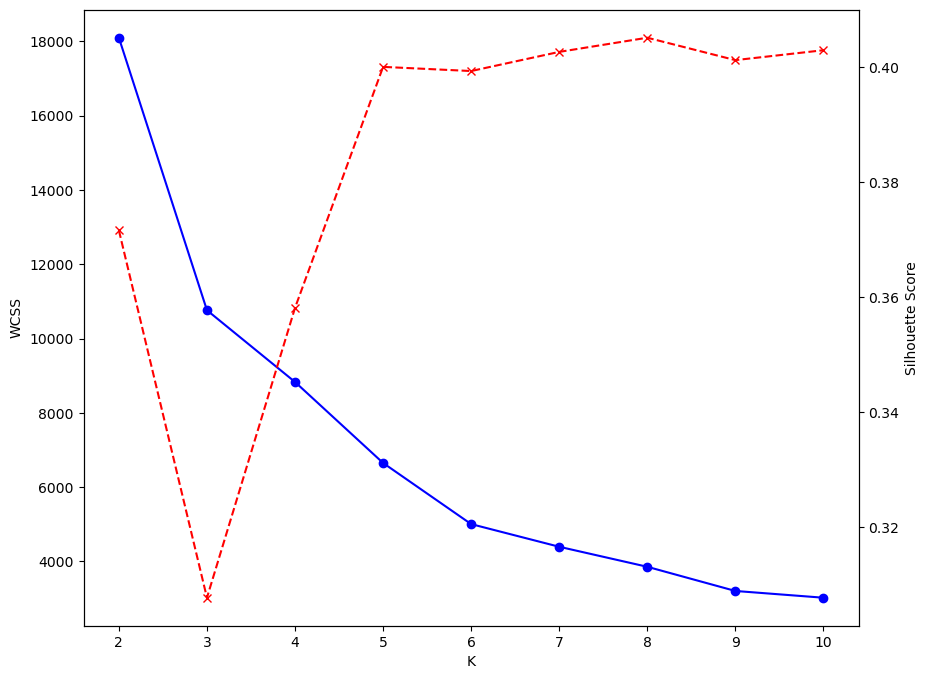

In [28]:
#combined plot 
k_range = range(2,11)
fig,ax1 = plt.subplots(figsize=(10,8))
ax1.plot(k_range,wcss[:len(k_range)],marker='o',color='blue')
ax1.set_ylabel("WCSS")
ax1.set_xlabel("K")

ax2 = ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red",linestyle="--")
ax2.set_ylabel('Silhouette Score')

In [29]:
## Clustering 

kmeans = KMeans(n_clusters=4,random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

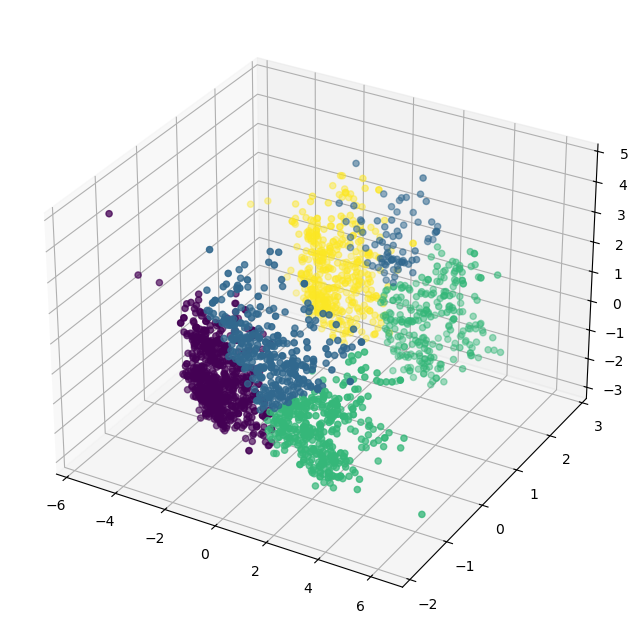

In [30]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)

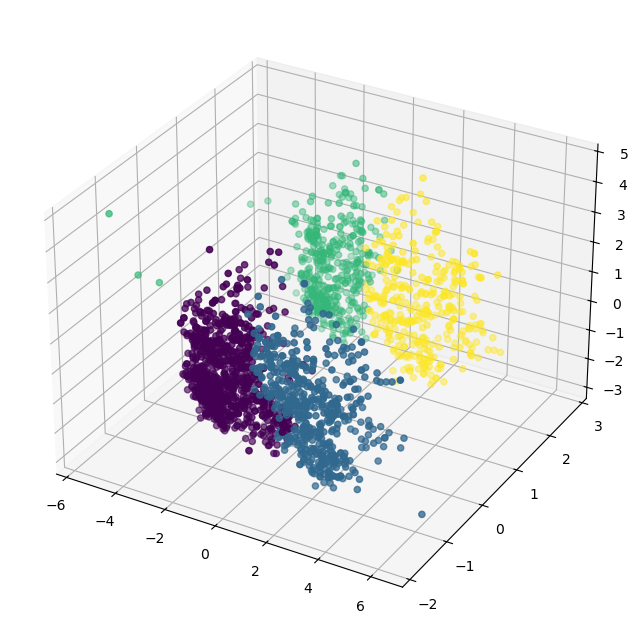

In [46]:
# Agglomerative Clustering
agg_clf = AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)


fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg);

### Characterization of Clusters

In [38]:
X["clusters"] = labels_agg
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Cutomer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


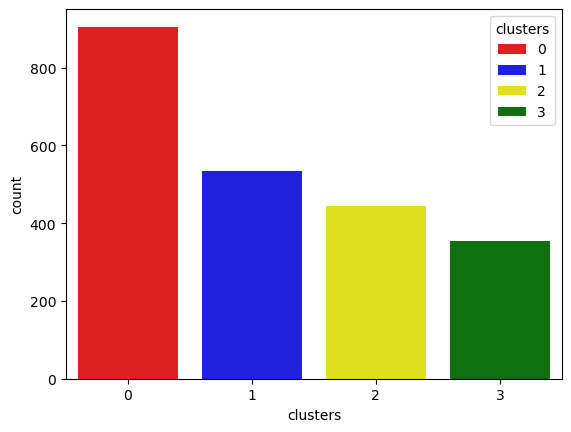

In [47]:
color_pal = ["red","blue","yellow","green"]
sns.countplot(x= X["clusters"],palette=color_pal,hue=X["clusters"]);

<Axes: xlabel='Total_Spending', ylabel='Income'>

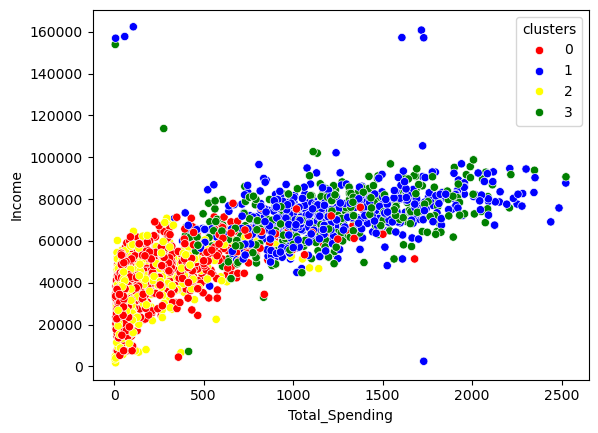

In [40]:
sns.scatterplot(x=X["Total_Spending"],y=X["Income"],
                hue=X["clusters"],palette=color_pal)

In [42]:
# Cluster Summary 
cluster_summary = X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Cutomer_Tenure_Days  Total_Spending  \
clus